# 05 — Market Gap Detection
Enriching supply data with population proxies to identify underserved districts.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

district = pd.read_csv('../data/processed/brick_district_summary.csv')

# Telangana district populations (Census 2011, most recent reliable data)
# Source: Census of India 2011, Telangana districts
population = {
    'Adilabad': 708972, 'Bhadradri Kothagudem': 1068457,
    'Hanumakonda': 793418, 'Hyderabad': 3943323,
    'Jagtial': 983414, 'Jangaon': 620278,
    'Jayashankar Bhupalpally': 596040, 'Jogulamba Gadwal': 638840,
    'Kamareddy': 972625, 'Karimnagar': 1097753,
    'Khammam': 1401639, 'Kumuram Bheem Asifabad': 573803,
    'Mahabubabad': 770170, 'Mancherial': 906225,
    'Medak': 767428, 'Medchal Malkajgiri': 2442975,
    'Mulugu': 362170, 'Nagarkurnool': 893418,
    'Nalgonda': 1738750, 'Narayanpet': 599402,
    'Nirmal': 707773, 'Nizamabad': 1529128,
    'Peddapalli': 795332, 'Rajanna Sircilla': 549453,
    'Ranga Reddy': 5296396, 'Sangareddy': 1324143,
    'Siddipet': 1000954, 'Suryapet': 1099561,
    'Vikarabad': 936332, 'Wanaparthy': 596786,
    'Warangal': 1268400, 'Yadadri Bhuvanagiri': 708701,
    'Nirmal': 707773
}

pop_df = pd.DataFrame(list(population.items()), columns=['Districts', 'population_2011'])
district = district.merge(pop_df, on='Districts', how='left')
print(f"Districts matched: {district['population_2011'].notna().sum()} of {len(district)}")
district.head()

Districts matched: 31 of 31


,Districts,factory_count,running_count,eco_count,fully_auto_count,closure_count,operational_rate,eco_share,closure_rate,population_2011
0,Adilabad,3,2,3,0,1,66.7,100.0,33.3,708972
1,Bhadradri Kothagudem,10,9,9,0,1,90.0,90.0,10.0,1068457
2,Hanumakonda,22,19,19,2,3,86.4,86.4,13.6,793418
3,Hyderabad,30,28,26,13,2,93.3,86.7,6.7,3943323
4,Jagtial,10,8,6,0,2,80.0,60.0,20.0,983414


In [11]:
# factories per 100k population
district['factories_per_100k'] = (
    district['factory_count'] / district['population_2011'] * 100000
).round(2)

# modern factories per 100k
district['modern_per_100k'] = (
    district['fully_auto_count'] / district['population_2011'] * 100000
).round(2)

# gap score: high population, low modern density
# normalize both to 0-1, then gap = population_norm * (1 - modern_norm)
district['pop_norm'] = (district['population_2011'] - district['population_2011'].min()) / \
                        (district['population_2011'].max() - district['population_2011'].min())

district['modern_norm'] = (district['modern_per_100k'] - district['modern_per_100k'].min()) / \
                           (district['modern_per_100k'].max() - district['modern_per_100k'].min())

district['gap_score'] = (district['pop_norm'] * (1 - district['modern_norm'])).round(3)

# top opportunities
top_gaps = district.nlargest(10, 'gap_score')[
    ['Districts', 'population_2011', 'factory_count', 
     'fully_auto_count', 'eco_share', 'gap_score']
]
print("Top 10 Market Gaps:")
print(top_gaps.to_string(index=False))

Top 10 Market Gaps:
           Districts  population_2011  factory_count  fully_auto_count  eco_share  gap_score
         Ranga Reddy          5296396              6                 2       83.3      0.933
           Hyderabad          3943323             30                13       86.7      0.327
            Nalgonda          1738750             13                 2       69.2      0.223
           Nizamabad          1529128              3                 1       33.3      0.209
             Khammam          1401639             11                 1      100.0      0.186
            Warangal          1268400              9                 0       66.7      0.184
          Sangareddy          1324143             11                 2       18.2      0.146
Bhadradri Kothagudem          1068457             10                 0       90.0      0.143
  Medchal Malkajgiri          2442975             42                10       76.2      0.134
             Jagtial           983414             

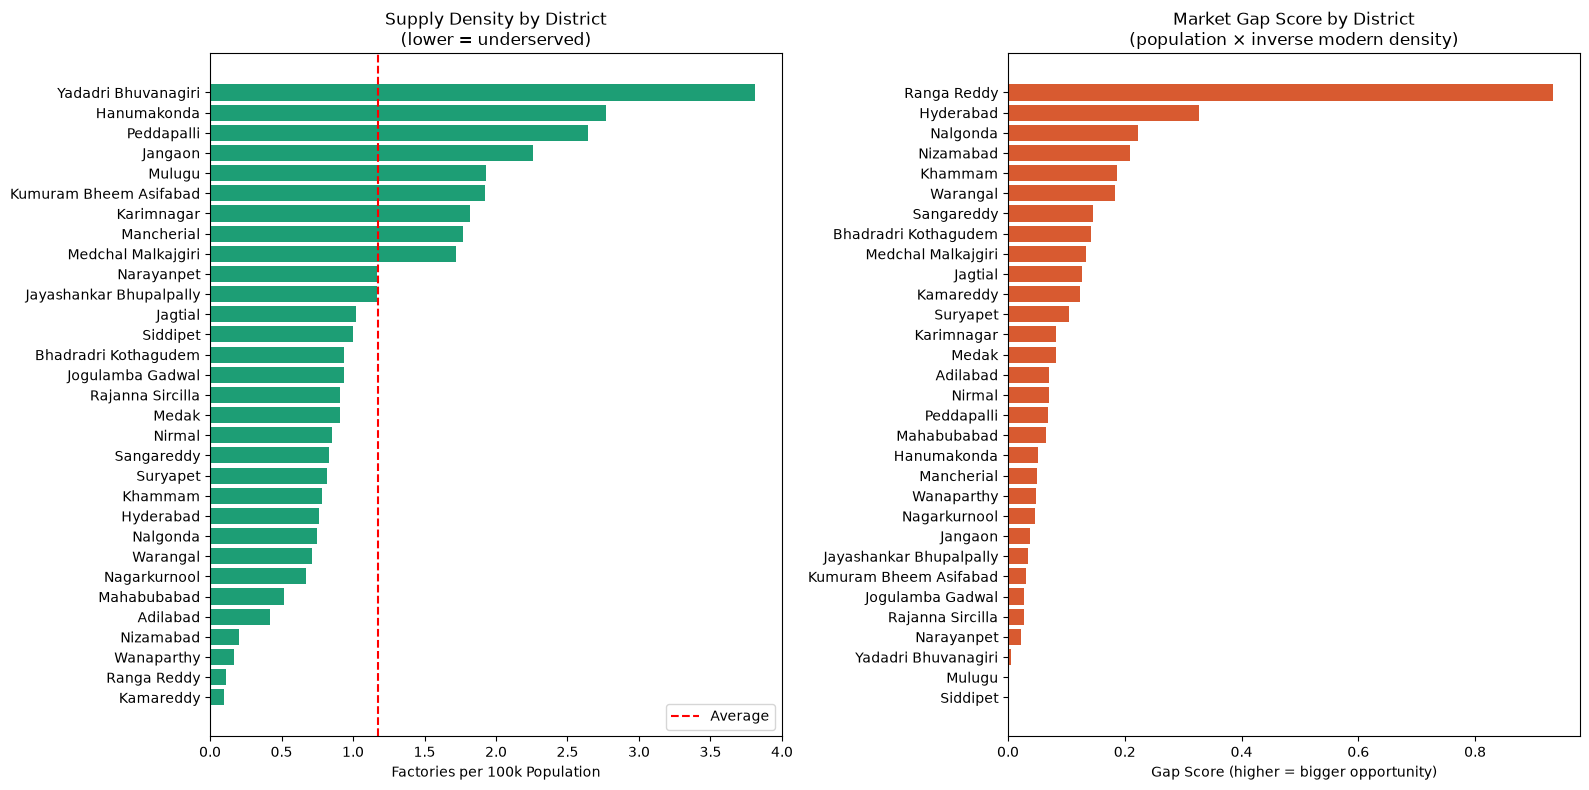

Chart saved ✓


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: factories per 100k population
district_sorted = district.sort_values('factories_per_100k', ascending=True)
axes[0].barh(district_sorted['Districts'], 
             district_sorted['factories_per_100k'], 
             color='#1D9E75')
axes[0].set_xlabel('Factories per 100k Population')
axes[0].set_title('Supply Density by District\n(lower = underserved)')
axes[0].axvline(x=district['factories_per_100k'].mean(), 
                color='red', linestyle='--', label='Average')
axes[0].legend()

# Chart 2: Gap score
district_sorted2 = district.sort_values('gap_score', ascending=True)
axes[1].barh(district_sorted2['Districts'], 
             district_sorted2['gap_score'], 
             color='#D85A30')
axes[1].set_xlabel('Gap Score (higher = bigger opportunity)')
axes[1].set_title('Market Gap Score by District\n(population × inverse modern density)')

plt.tight_layout()
plt.savefig('../reports/market_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [16]:
# Factories per 1000 households (your better denominator)
district['factories_per_1000_hh'] = (
    district['factory_count'] / district['households_2011'] * 1000
).round(3)

district['modern_per_1000_hh'] = (
    district['fully_auto_count'] / district['households_2011'] * 1000
).round(3)

# Gap score using household density
hh_norm = (district['households_2011'] - district['households_2011'].min()) / \
           (district['households_2011'].max() - district['households_2011'].min())

modern_hh_norm = (district['modern_per_1000_hh'] - district['modern_per_1000_hh'].min()) / \
                  (district['modern_per_1000_hh'].max() - district['modern_per_1000_hh'].min())

district['gap_score_hh'] = (hh_norm * (1 - modern_hh_norm)).round(3)

# Top 10 results
top10 = district.nlargest(10, 'gap_score_hh')[
    ['Districts', 'households_2011', 'factory_count',
     'fully_auto_count', 'eco_share', 'factories_per_1000_hh', 
     'modern_per_1000_hh', 'gap_score_hh']
]
print("Top 10 Market Gaps (household-based):")
print(top10.to_string(index=False))

Top 10 Market Gaps (household-based):
           Districts  households_2011  factory_count  fully_auto_count  eco_share  factories_per_1000_hh  modern_per_1000_hh  gap_score_hh
         Ranga Reddy          1342187              6                 2       83.3                  0.004               0.001         0.960
           Hyderabad          1005646             30                13       86.7                  0.030               0.013         0.351
            Nalgonda           421876             13                 2       69.2                  0.031               0.005         0.214
           Nizamabad           369871              3                 1       33.3                  0.008               0.003         0.199
             Khammam           345231             11                 1      100.0                  0.032               0.003         0.181
            Warangal           306543              9                 0       66.7                  0.029               0.000    

In [17]:
district.to_csv('../data/processed/brick_gap_analysis.csv', index=False)
print("Gap analysis exported ✓")

Gap analysis exported ✓
